In [9]:
import glob
from lalframe.utils import get_channels
from gwpy.timeseries import TimeSeries
from gwpy.timeseries import TimeSeriesDict
from gwpy.timeseries import StateVector

import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

### Finding science segments of KAGRA strain data in O4 run
The science segments are recorded in text files. The recommanded science segment file of o4a is `/home/detchar/Segments/K1-GRD_SCIENCE_MODE_NO_IPC_ERROR/K1-GRD_SCIENCE_MODE_NO_IPC_ERROR_MARGIIN_3SEC_SEGMENT_UTC_O4a.txt` and the segment file for o4c is `/home/detchar/Segments/K1-GRD_SCIENCE_MODE_NO_IPC_ERROR/K1-GRD_SCIENCE_MODE_NO_IPC_ERROR_MARGIIN_3SEC_SEGMENT_UTC_O4c.txt`.

These two files have been copied into the directory `Segments` in this repository. However, these files may be updated in the future. It is always important to figure out the information of science segments before we start to read any data.

In [10]:
# Read the segment file and get the science segments into a list.
# segment_file = "../Segments/K1-GRD_SCIENCE_MODE_NO_IPC_ERROR_MARGIIN_3SEC_SEGMENT_UTC_O4a.txt"
segment_file = "../Segments/K1-GRD_SCIENCE_MODE_NO_IPC_ERROR_MARGIIN_3SEC_SEGMENT_UTC_O4c.txt"
with open(segment_file, "r") as f:
  science_segments = []
  lines = f.readlines()
  for line in lines:
    start = int(line.strip().split(" ")[0])
    end = int(line.strip().split(" ")[1])
    duration = end - start
    science_segments.append((start, end, duration))

# Check the science segments.
print(f"{len(science_segments)} science segments found in {segment_file}.")
print(science_segments[:3])

296 science segments found in ../Segments/K1-GRD_SCIENCE_MODE_NO_IPC_ERROR_MARGIIN_3SEC_SEGMENT_UTC_O4c.txt.
[(1433689218, 1433695889, 6671), (1433697776, 1433720847, 23071), (1433722650, 1433722691, 41)]


### Reading data on kmst2-01
The strain data can be found in the directory `/data/LVK/low-latency`. KAGRA O4a strain data can be found in `ll_merged_A/K1` and KAGRA o4c strain data can be found in `ll_merged/K1`.

In [11]:
# Choose the data directory.
# data_dir = "/data/LVK/low-latency/ll_merged_A/K1"
data_dir = "/data/LVK/low-latency/ll_merged/K1"

# Find all gwf files in the data directory.
gwf_files = glob.glob(f"{data_dir}/*.gwf")
gwf_files = sorted(gwf_files)
print(f"Found {len(gwf_files)} gwf files in {data_dir}.")
print(gwf_files[:3])

Found 18475 gwf files in /data/LVK/low-latency/ll_merged/K1.
['/data/LVK/low-latency/ll_merged/K1/K-K1_llhoft-1385529344-4096.gwf', '/data/LVK/low-latency/ll_merged/K1/K-K1_llhoft-1385533440-4096.gwf', '/data/LVK/low-latency/ll_merged/K1/K-K1_llhoft-1385615360-4096.gwf']


We can see that the name of a gwf file indicates useful information such as the detector, label, GPS start time and duration. It is a good practice to specify these information correctly in the file name.

We can get the channel names in a gwf file using the command `lalfr-dump GWF_FILE`. In Python, we can use `lalframe.utils.frtools.get_channels` to get the channel names in a gwf file.

In [12]:
channels = get_channels(gwf_files[0])
print(channels)

['K1:CAL-STATE_VECTOR_C00', 'K1:CAL-STRAIN_C00', 'K1:DET-DQ_STATE_VECTOR', 'K1:GRD-IFO_STATE_N']


`K1:CAL-STRAIN_C00` is the channel of the strain data, other channels are used to check the data quality. For KAGRA data, `K1:GRD-IFO_STATE_N`=1000 indicates that the strain data is in science mode and can be used for scientific data analysis.

Now let's get the time series data according to the science segments and check all the information we can get. Let's get 512 second of strain data in a science segment.

In [13]:
# Filter out the segment with duration larger than 600 second:
science_segments_le600 = []
for seg in science_segments:
  if seg[2] >= 600:
    science_segments_le600.append(seg)

print(f"{len(science_segments_le600)} science segments are longer than 600 s.")
print(science_segments_le600[:3])

# Find the gwf files we need to read the data
start = science_segments_le600[0][0] + 182
duration = 512
end = start + duration
print(f"Target segment: ({start}, {end}).")
source = []
for gwf in gwf_files:
  gwf_start = int(gwf.split("/")[-1].split("-")[-2])
  gwf_duration = int(gwf.split("/")[-1].split("-")[-1].split(".")[0])
  gwf_end = gwf_start + gwf_duration

  # We only need the gwf files that overlap with our target segment.
  overlap_head = (gwf_start <= start and start < gwf_end)
  overlap_tail = (gwf_start < end and end <= gwf_end)
  inside = (start <= gwf_start and gwf_end <= end)
  cover = (gwf_start < start and end < gwf_end)
  overlap = (overlap_head or overlap_tail or inside or cover)
  if overlap:
    source.append(gwf)

print(f"The gwf files: {source} overlap with the target segment: {(start, end)}.")

269 science segments are longer than 600 s.
[(1433689218, 1433695889, 6671), (1433697776, 1433720847, 23071), (1433741276, 1433742790, 1514)]
Target segment: (1433689400, 1433689912).
The gwf files: ['/data/LVK/low-latency/ll_merged/K1/K-K1_llhoft-1433686016-4096.gwf'] overlap with the target segment: (1433689400, 1433689912).


We use `gwpy.timeseries.TimeSeries` to read the target time series data.

['K1:CAL-STATE_VECTOR_C00', 'K1:CAL-STRAIN_C00', 'K1:DET-DQ_STATE_VECTOR', 'K1:GRD-IFO_STATE_N']
TimeSeries([ 3.45860673e-17,  3.29312386e-17,  3.43628406e-17,
            ..., -2.18081773e-17, -2.17505920e-17,
            -2.22184320e-17]
           unit: dimensionless,
           t0: 1433689400.0 s,
           dt: 6.103515625e-05 s,
           name: K1:CAL-STRAIN_C00,
           channel: K1:CAL-STRAIN_C00)
The sample rate of the time series is 16384.0 Hz, the gps start time is 1433689400.0 s, the duration is 512.0 s, the unit is .


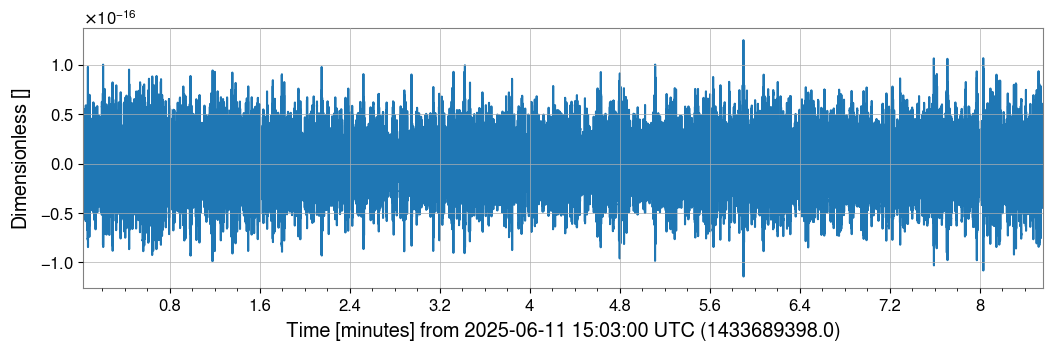

In [15]:
print(channels)

channel = "K1:CAL-STRAIN_C00"
# channel = "K1:GRD-IFO_STATE_N"
ts = TimeSeries.read(
  source=source,
  channel=channel,
  start=start,
  end=end,
)
print(ts)
print(f"The sample rate of the time series is {ts.sample_rate}, the gps start time is {ts.t0}, the duration is {ts.duration}, the unit is {ts.unit}.")

# Plot the strain time series.
ts.plot().show()

If we want to read in multiple channels at one time, we can use `gwpy.timeseries.TimeSeriesDict` to read the data.

The channel in ts_dict: odict_keys(['K1:CAL-STATE_VECTOR_C00', 'K1:CAL-STRAIN_C00', 'K1:DET-DQ_STATE_VECTOR', 'K1:GRD-IFO_STATE_N']).


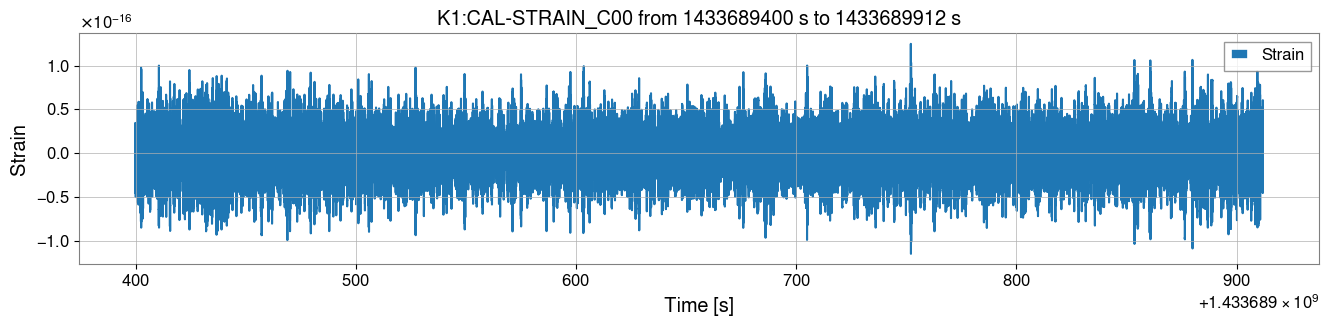

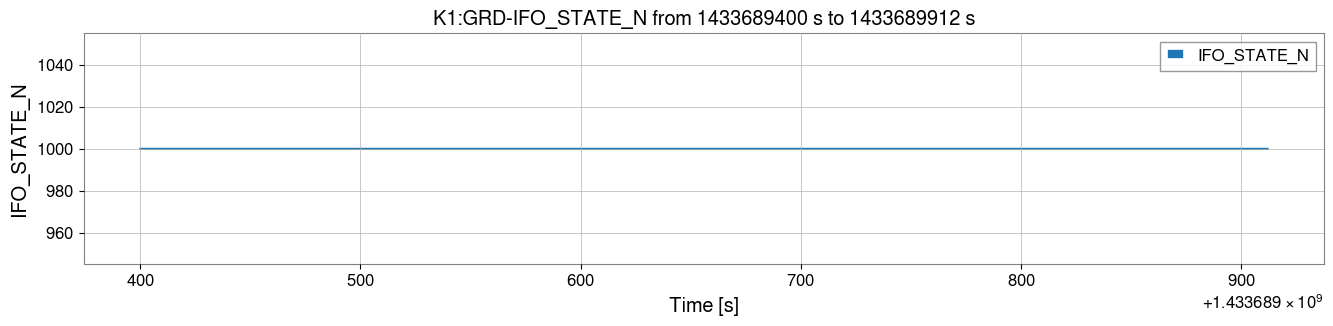

In [16]:
ts_dict = TimeSeriesDict.read(
  source=source,
  channels=channels,
  start=start,
  end=end,
)
# print(ts_dict)
print(f"The channel in ts_dict: {ts_dict.keys()}.")

# Strain.
ts = ts_dict["K1:CAL-STRAIN_C00"]
plt.figure(figsize=[16,3])
plt.plot(ts.times, ts, label="Strain")
plt.title(f"{ts.channel} from {start} s to {end} s")
plt.xlabel("Time [s]")
plt.ylabel("Strain")
plt.legend()
plt.show()

# IFO_STATE_N
ts = ts_dict["K1:GRD-IFO_STATE_N"]
plt.figure(figsize=[16,3])
plt.plot(ts.times, ts, label="IFO_STATE_N")
plt.title(f"{ts.channel} from {start} s to {end} s")
plt.xlabel("Time [s]")
plt.ylabel("IFO_STATE_N")
plt.legend()
plt.show()

State vector is used to specify the state of data quality. There are different bits used to specify the state of the data.

TimeSeries([2023, 2023, 2023, ..., 2023, 2023, 2023]
           unit: dimensionless,
           t0: 1433689400.0 s,
           dt: 0.0625 s,
           name: K1:CAL-STATE_VECTOR_C00,
           channel: K1:CAL-STATE_VECTOR_C00)


StateVector([2023, 2023, 2023, ..., 2023, 2023, 2023]
            unit: dimensionless,
            t0: 1433689400.0 s,
            dt: 0.0625 s,
            name: K1:CAL-STATE_VECTOR_C00,
            channel: K1:CAL-STATE_VECTOR_C00,
            bits: Bits(0: HOFT_OK
                        1: OBS_INTENT
                        2: SCIENCE_MODE
                        4: NO_GAP
                        5: NO_STOCH_HW_INJ
                        6: NO_CBC_HW_INJ
                        7: NO_BURST_HW_INJ
                        8: NO_DETCHAR_HW_INJ
                        9: NO_CW_HW_INJ
                        10: NO_UNPLANNED_HW_INJ,
                        channel=K1:CAL-STATE_VECTOR_C00,
                        epoch=1433689400.0))
2023


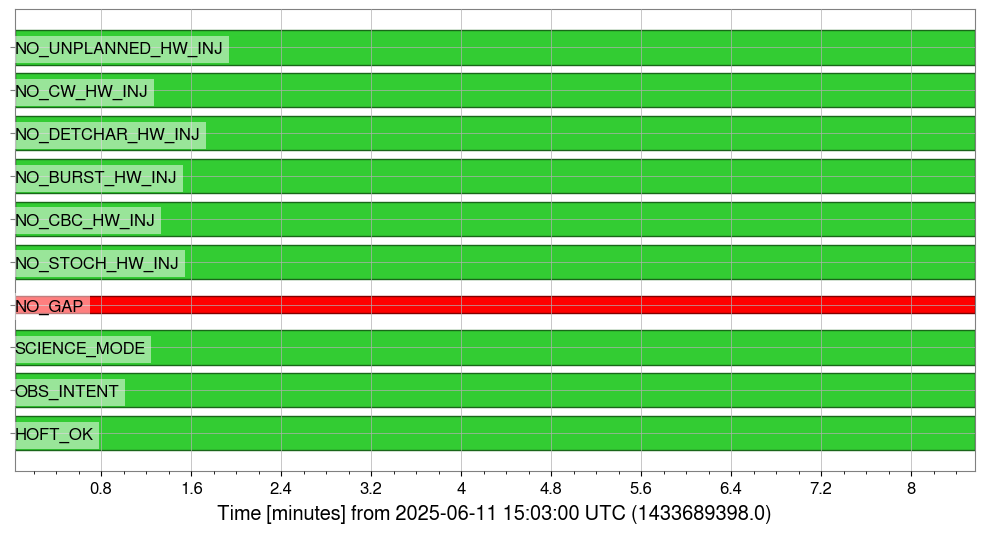

In [21]:
print(ts_dict["K1:CAL-STATE_VECTOR_C00"])
channel = "K1:CAL-STATE_VECTOR_C00"
bits = [
  "HOFT_OK",
  "OBS_INTENT?",
  "SCIENCE_MODE",
  None,
  "NO_GAP",
  "NO_STOCH_HW_INJ",
  "NO_CBC_HW_INJ",
  "NO_BURST_HW_INJ",
  "NO_DETCHAR_HW_INJ",
  "NO_CW_HW_INJ",
  "NO_UNPLANNED_HW_INJ",
]
state_vector = StateVector.read(
  source=source,
  channel=channel,
  bits=bits,
  start=start,
  end=end,
)
print(state_vector)
# state_value = 2**0 + 2**2 + 2**4 + 2**5 + 2**6 + 2**7 + 2**8 + 2**9 + 2**10
state_value = 2**0 + 2**1 + 2**2 + 2**5 + 2**6 + 2**7 + 2**8 + 2**9 + 2**10
print(state_value)

# Plot the state vector.
state_vector.plot(insetlabels=True).show()

TimeSeries([8190, 8190, 8190, ..., 8190, 8190, 8190]
           unit: dimensionless,
           t0: 1433689400.0 s,
           dt: 0.0625 s,
           name: K1:DET-DQ_STATE_VECTOR,
           channel: K1:DET-DQ_STATE_VECTOR)
StateVector([8190, 8190, 8190, ..., 8190, 8190, 8190]
            unit: dimensionless,
            t0: 1433689400.0 s,
            dt: 0.0625 s,
            name: K1:DET-DQ_STATE_VECTOR,
            channel: K1:DET-DQ_STATE_VECTOR,
            bits: Bits(0: Odd_PARITY
                        1: IFO_LOCKED
                        2: NO_DIFFERENCE_ON_SDF
                        3: SCIENCE_MODE
                        4: DCPDS_NO_OVERFLOW
                        5: ETMX_NO_OVERFLOW
                        6: ETMY_NO_OVERFLOW
                        7: NO_STOCH_HW_INJ
                        8: NO_CBC_HW_INJ
                        9: NO_BURST_HW_INJ
                        10: NO_DETCHAR_HW_INJ
                        11: NO_CW_HW_INJ
                        12: NO_U

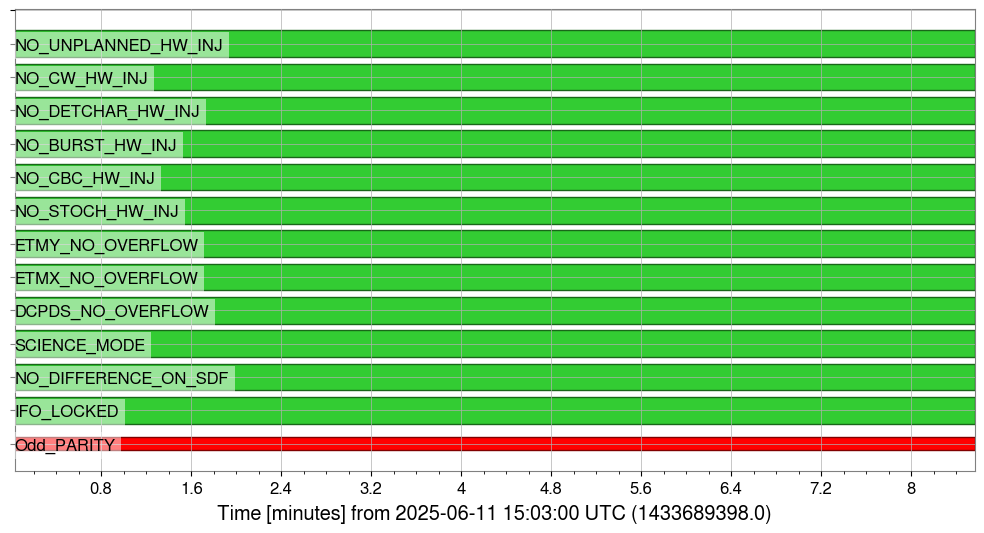

In [28]:
print(ts_dict["K1:DET-DQ_STATE_VECTOR"])
channel = "K1:DET-DQ_STATE_VECTOR"
bits = [
  "Odd_PARITY",
  "IFO_LOCKED",
  "NO_DIFFERENCE_ON_SDF",
  "SCIENCE_MODE",
  "DCPDS_NO_OVERFLOW",
  "ETMX_NO_OVERFLOW",
  "ETMY_NO_OVERFLOW",
  "NO_STOCH_HW_INJ",
  "NO_CBC_HW_INJ",
  "NO_BURST_HW_INJ",
  "NO_DETCHAR_HW_INJ",
  "NO_CW_HW_INJ",
  "NO_UNPLANNED_HW_INJ",
]
state_vector = StateVector.read(
  source=source,
  channel=channel,
  bits=bits,
  start=start,
  end=end,
)
print(state_vector)
state_value = 0*2**0 + 2**1 + 2**2 + 2**3 + 2**4 + 2**5 + 2**6 + 2**7 + 2**8 + 2**9 + 2**10 + 2**11 + 2**12
print(state_value)

# Plot the state vector.
state_vector.plot(insetlabels=True).show()